In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

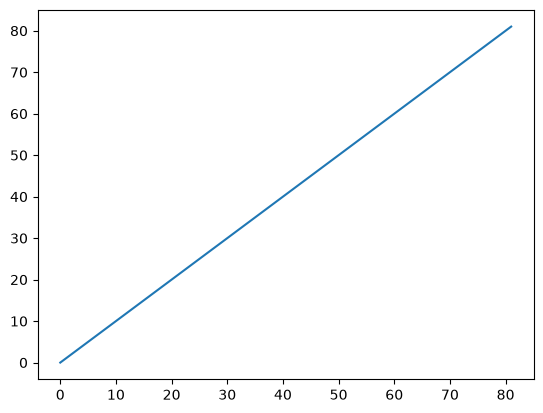

In [2]:
x = [k**2 for k in range(10)]
y = [x**2 for x in range(10)]
plt.plot(x,y)

In [3]:
x = torch.randn(1000, 10)

print(x.shape)
print(x.mean())
print(x.std())


torch.Size([1000, 10])
tensor(-0.0030)
tensor(0.9932)


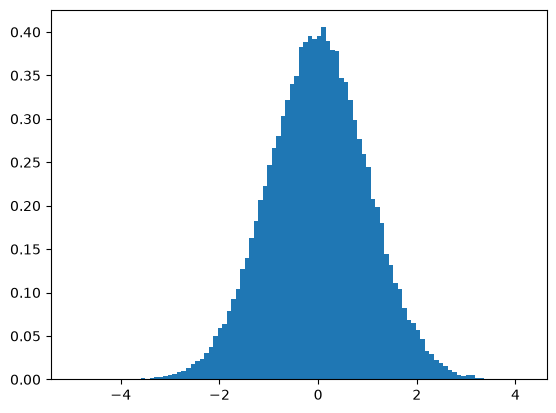

In [4]:
x = torch.randn(100000)

plt.hist(x, bins=100, density=True)
plt.show()

In [5]:
x = torch.tensor([2., 4., 6., 8.])

print("x       =", x)
print("mean    =", x.mean())
print("std     =", x.std())

x       = tensor([2., 4., 6., 8.])
mean    = tensor(5.)
std     = tensor(2.5820)


mean = -0.0024356148205697536
std  = 0.9976230263710022


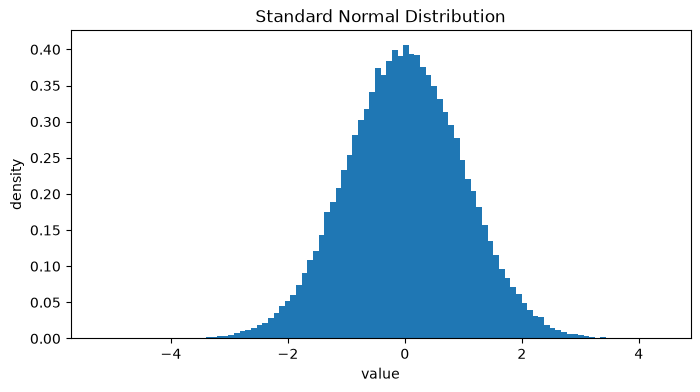

In [6]:
x = torch.randn(100000)

print("mean =", x.mean().item())
print("std  =", x.std().item())

plt.figure(figsize=(8, 4))
plt.hist(x.numpy(), bins=100, density=True)
plt.xlabel("value")
plt.ylabel("density")
plt.title("Standard Normal Distribution")
plt.show()

In [7]:
x = torch.randn(1000, 10)
W = torch.randn(10, 200)

y = x @ W

print("x shape:", x.shape)
print("W shape:", W.shape)
print("y shape:", y.shape)

print()
print("x mean:", x.mean().item())
print("x std :", x.std().item())

print()
print("W mean:", W.mean().item())
print("W std :", W.std().item())

print()
print("y mean:", y.mean().item())
print("y std :", y.std().item())

x shape: torch.Size([1000, 10])
W shape: torch.Size([10, 200])
y shape: torch.Size([1000, 200])

x mean: -0.0033951213117688894
x std : 0.9921703338623047

W mean: 0.002582611981779337
W std : 0.9826659560203552

y mean: 0.00866217166185379
y std : 3.082658290863037


In [8]:
x = torch.randn(100000)

for scale in [0.5, 1.0, 2.0, 3.0, 5.0]:
    y = torch.tanh(x * scale)

    saturated = (y.abs() > 0.95).float().mean()

    print(
        f"input std = {scale:.1f} | "
        f"output std = {y.std():.3f} | "
        f"saturated = {saturated * 100:.2f}%"
    )

input std = 0.5 | output std = 0.417 | saturated = 0.03%
input std = 1.0 | output std = 0.628 | saturated = 6.71%
input std = 2.0 | output std = 0.797 | saturated = 35.86%
input std = 3.0 | output std = 0.864 | saturated = 54.25%
input std = 5.0 | output std = 0.918 | saturated = 71.48%


In [9]:
x = torch.randn(10000, 10)

for weight_std in [1.0, 0.5, 0.3, 0.2, 0.1]:
    W = torch.randn(10, 200) * weight_std
    y = x @ W

    print(
        f"W std = {weight_std:.2f} | "
        f"y std = {y.std():.3f}"
    )

W std = 1.00 | y std = 3.174
W std = 0.50 | y std = 1.580
W std = 0.30 | y std = 0.947
W std = 0.20 | y std = 0.638
W std = 0.10 | y std = 0.321


In [10]:
for fan_in in [5, 10, 50, 100, 500]:

    x = torch.randn(10000, fan_in)

    weight_std = 1 / (fan_in ** 0.5)
    W = torch.randn(fan_in, 200) * weight_std

    y = x @ W

    print(
        f"fan_in = {fan_in:3d} | "
        f"W std = {weight_std:.4f} | "
        f"y std = {y.std():.3f}"
    )

fan_in =   5 | W std = 0.4472 | y std = 0.993
fan_in =  10 | W std = 0.3162 | y std = 0.992
fan_in =  50 | W std = 0.1414 | y std = 0.986
fan_in = 100 | W std = 0.1000 | y std = 0.996
fan_in = 500 | W std = 0.0447 | y std = 1.001


In [11]:
x = torch.randn(100000)

for scale in [0.2, 0.5, 1.0, 1.2, 1.5, 5/3, 2.0]:

    y = torch.tanh(x * scale)

    saturated = (y.abs() > 0.95).float().mean()

    derivative = 1 - y**2

    print(
        f"scale = {scale:.3f} | "
        f"output std = {y.std():.3f} | "
        f"saturated = {saturated * 100:.2f}% | "
        f"mean |tanh'| = {derivative.abs().mean():.3f}"
    )

scale = 0.200 | output std = 0.192 | saturated = 0.00% | mean |tanh'| = 0.963
scale = 0.500 | output std = 0.416 | saturated = 0.03% | mean |tanh'| = 0.827
scale = 1.000 | output std = 0.627 | saturated = 6.66% | mean |tanh'| = 0.606
scale = 1.200 | output std = 0.678 | saturated = 12.64% | mean |tanh'| = 0.540
scale = 1.500 | output std = 0.735 | saturated = 21.98% | mean |tanh'| = 0.460
scale = 1.667 | output std = 0.759 | saturated = 26.96% | mean |tanh'| = 0.424
scale = 2.000 | output std = 0.797 | saturated = 35.78% | mean |tanh'| = 0.365


tensor(0.9991) tensor(0.0010)


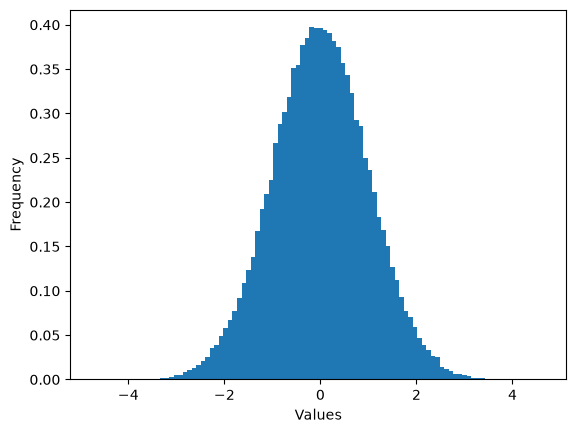

In [12]:
k = torch.randn(100000)
print(k.std(), k.mean())
plt.hist(k, bins=100, density=True)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

In [13]:
inp = torch.randn(32,10)
x = torch.randn(200, 10)

h = inp @ x.T
h.shape, h.mean(), h.std()

(torch.Size([32, 200]), tensor(0.0422), tensor(3.1770))

In [17]:
import torch
import torch.nn.functional as F

torch.manual_seed(42)

# Small toy classification problem:
# 1000 examples, 30 input features, 27 possible outputs

X = torch.randn(1000, 30)
y = torch.randint(0, 27, (1000,))

# Deliberately BAD initialization
W = torch.randn(30, 27)
b = torch.randn(27)

k = X @ W
logits = X @ W + b

loss = F.cross_entropy(logits, y)

print(logits.shape, k.shape)
print("logits mean:", logits.mean().item())
print("logits std :", logits.std().item())
print("loss       :", loss.item())
print("expected random loss:", torch.log(torch.tensor(27.)).item())

torch.Size([1000, 27]) torch.Size([1000, 27])
logits mean: -0.29717597365379333
logits std : 5.505015850067139
loss       : 11.399413108825684
expected random loss: 3.295836925506592


In [18]:
torch.manual_seed(42)

X = torch.randn(1000, 30)
y = torch.randint(0, 27, (1000,))

for weight_std in [1.0, 0.1, 0.01, 0.001]:

    W = torch.randn(30, 27) * weight_std
    b = torch.zeros(27)

    logits = X @ W + b
    loss = F.cross_entropy(logits, y)

    probabilities = F.softmax(logits, dim=1)
    max_probability = probabilities.max(dim=1).values.mean()

    print(
        f"W std = {weight_std:>5.3f} | "
        f"logits std = {logits.std():>6.3f} | "
        f"avg max prob = {max_probability:.3f} | "
        f"loss = {loss:.3f}"
    )

W std = 1.000 | logits std =  5.456 | avg max prob = 0.740 | loss = 11.202
W std = 0.100 | logits std =  0.551 | avg max prob = 0.098 | loss = 3.448
W std = 0.010 | logits std =  0.054 | avg max prob = 0.041 | loss = 3.298
W std = 0.001 | logits std =  0.006 | avg max prob = 0.037 | loss = 3.296


In [25]:
torch.manual_seed(42)

x = torch.randn(1000,30)

for weight_std in [1.0, 0.2, 1 / (30 ** 0.5)]:
    w = torch.randn(30,27) * weight_std
    pre_act = x @ w
    h = torch.tanh(pre_act)
    
    saturated = (h.abs() > 0.97).float().mean()
    print(
        f"W std = {weight_std:.3f} | "
        f"pre-tanh std = {pre_act.std():.3f} | "
        f"tanh std = {h.std():.3f} | "
        f"saturated = {saturated * 100:.2f}%"
    )

W std = 1.000 | pre-tanh std = 5.425 | tanh std = 0.923 | saturated = 69.22%
W std = 0.200 | pre-tanh std = 1.117 | tanh std = 0.655 | saturated = 6.19%
W std = 0.183 | pre-tanh std = 0.996 | tanh std = 0.625 | saturated = 3.72%


In [26]:
torch.manual_seed(42)

x = torch.randn(10000, 30)

for gain in [1.0, 1.2, 1.5, 5/3, 2.0]:

    weight_std = gain / (30 ** 0.5)

    W = torch.randn(30, 200) * weight_std

    pre_activation = x @ W
    h = torch.tanh(pre_activation)

    saturated = (h.abs() > 0.97).float().mean()

    derivative = 1 - h**2

    print(
        f"gain = {gain:.3f} | "
        f"W std = {weight_std:.3f} | "
        f"pre std = {pre_activation.std():.3f} | "
        f"tanh std = {h.std():.3f} | "
        f"saturated = {saturated * 100:.2f}% | "
        f"mean |tanh'| = {derivative.mean():.3f}"
    )

gain = 1.000 | W std = 0.183 | pre std = 0.992 | tanh std = 0.621 | saturated = 3.70% | mean |tanh'| = 0.615
gain = 1.200 | W std = 0.219 | pre std = 1.187 | tanh std = 0.671 | saturated = 7.81% | mean |tanh'| = 0.550
gain = 1.500 | W std = 0.274 | pre std = 1.509 | tanh std = 0.732 | saturated = 16.20% | mean |tanh'| = 0.464
gain = 1.667 | W std = 0.304 | pre std = 1.705 | tanh std = 0.760 | saturated = 21.33% | mean |tanh'| = 0.423
gain = 2.000 | W std = 0.365 | pre std = 2.013 | tanh std = 0.794 | saturated = 29.20% | mean |tanh'| = 0.369
